#### <span style="color: deepskyblue;">Analiza dotycząca oferowanych powierzchni nieruchomości w ujęciu geograficznym   </span>


In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as ss
import seaborn as sns
import missingno as msno
import plotly.express as px

%matplotlib inline 
%config InlineBackend.figure_format = 'retina'

df = pd.read_csv("../data/apartments_clean.csv", sep=';', encoding="cp1250")
df.head(1)

C:\Users\Grażyna\AppData\Local\Temp\ipykernel_11928\48487720.py:12: DtypeWarning: Columns (0: address) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/apartments_clean.csv", sep=';', encoding="cp1250")


,id,category,title,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,...,Playground,Pool,Refrigerator,Storage,TV,Tennis,View,Washer Dryer,Wood Floors,price_per_sqft
0,5668640009,housing/rent/apartment,One BR 507 & 509 Esplanade,1.0,1.0,USD,No,Thumbnail,Cats,2195.0,...,0,0,0,0,0,0,0,0,0,4.049815


Skróty stref czasowych użyte w tabeli df_state:
- EST (Wschodnia), 
- CST (Centralna), 
- MST (Górska), 
- PST (Pacyficzna), 
- AKST (Alaska), 
- HST (Hawaje). 

Plik grupujący stany USA wg różnych kategorii pozyskany jest z pomocą AI ze strony U.S. Census Bureau (Biuro Spisu Ludności USA).</BR> 
Oznaczenie „Tak” w kolumnach <span style="color: deepskyblue;">Stan rolniczy</span>, <span style="color: deepskyblue;">Stan przemysłowy</span>, <span style="color: deepskyblue;">Ważny turystycznie</span> wskazuje,</BR> że dany sektor stanowi kluczowy, wyróżniający się filar gospodarki lub tożsamości stanu na tle reszty kraju 

In [3]:
df_state = pd.read_csv("../data/przypisanie_stanowUSA.csv", sep=';', encoding="cp1250")
df_state.head(1)

,Stan,Skrot,Region,Strefa czasowa,Stan rolniczy,Stan przemyslowy,Wazny turystycznie
0,Alabama,AL,South,CST / EST,Tak,Tak,Nie


In [4]:

# dołącz nazwę stanu
df = df.merge(
    df_state[['Skrot', 'Stan']],
    left_on='state',
    right_on='Skrot',
    how='left'
)
# usuń pomocniczą kolumnę
df = df.drop(columns='Skrot')

# dołącz region
df = df.merge(
    df_state[['Skrot', 'Region']],
    left_on='state',
    right_on='Skrot',
    how='left'
)
# usuń pomocniczą kolumnę
df = df.drop(columns='Skrot')

# dołącz Strefa czasowa
df = df.merge(
    df_state[['Skrot', 'Strefa czasowa']],
    left_on='state',
    right_on='Skrot',
    how='left'
)
# usuń pomocniczą kolumnę
df = df.drop(columns='Skrot')

# dołącz Stan rolniczy
df = df.merge(
    df_state[['Skrot', 'Stan rolniczy']],
    left_on='state',
    right_on='Skrot',
    how='left'
)
# usuń pomocniczą kolumnę
df = df.drop(columns='Skrot')

# dołącz Stan przemyslowy
df = df.merge(
    df_state[['Skrot', 'Stan przemyslowy']],
    left_on='state',
    right_on='Skrot',
    how='left'
)
# usuń pomocniczą kolumnę
df = df.drop(columns='Skrot')

# dołącz Wazny turystycznie
df = df.merge(
    df_state[['Skrot', 'Wazny turystycznie']],
    left_on='state',
    right_on='Skrot',
    how='left'
)
# usuń pomocniczą kolumnę
df = df.drop(columns='Skrot')

df.head(1)

,id,category,title,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,...,View,Washer Dryer,Wood Floors,price_per_sqft,Stan,Region,Strefa czasowa,Stan rolniczy,Stan przemyslowy,Wazny turystycznie
0,5668640009,housing/rent/apartment,One BR 507 & 509 Esplanade,1.0,1.0,USD,No,Thumbnail,Cats,2195.0,...,0,0,0,4.049815,California,West,PST,Tak,Tak,Tak


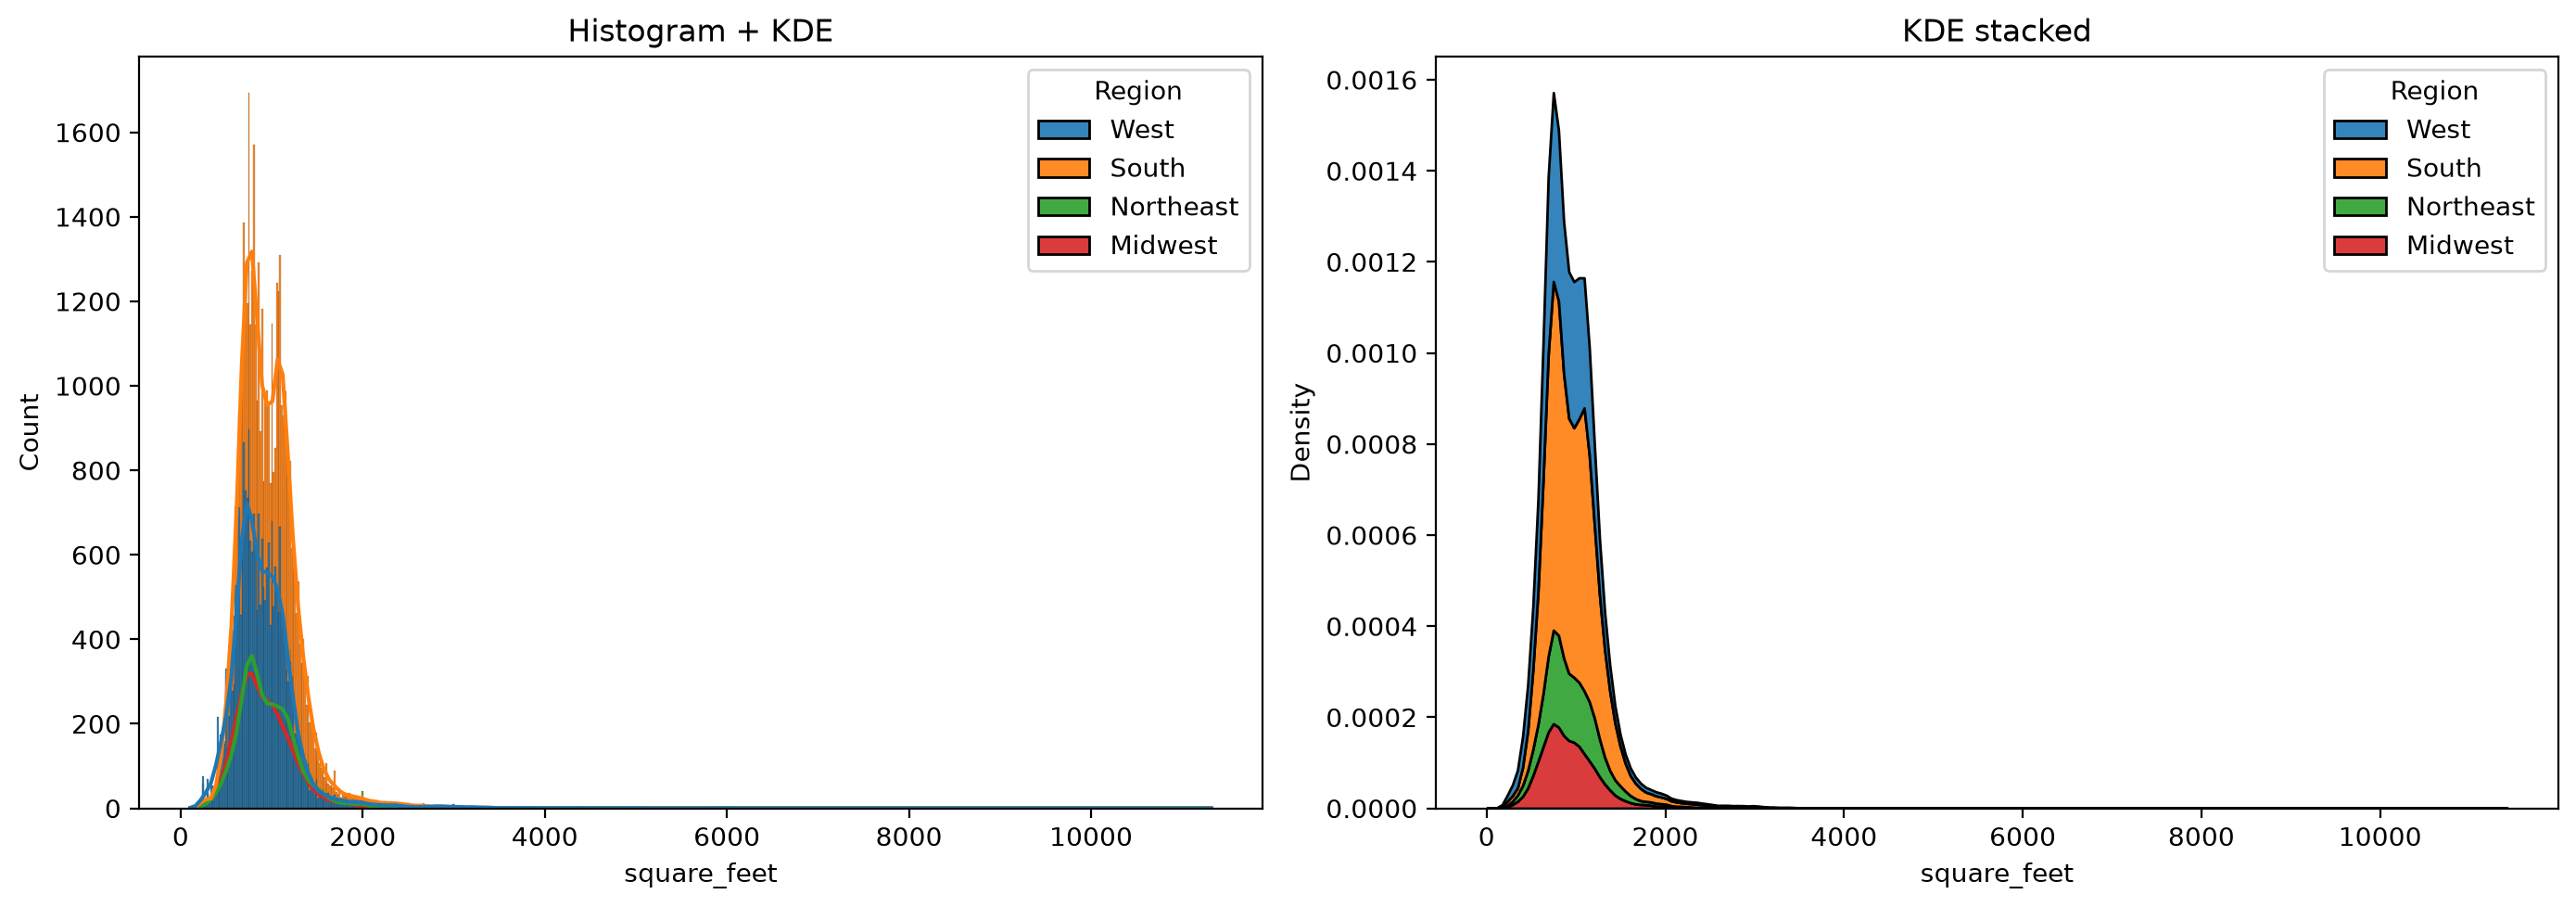

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    df,
    x='square_feet',
    kde=True,
    hue='Region',
    alpha=.9,
    ax=axes[0]
)
axes[0].set_title('Histogram + KDE')

sns.kdeplot(
    df,
    x='square_feet',
    hue='Region',
    alpha=.9,
    multiple='stack',
    ax=axes[1]
)
axes[1].set_title('KDE stacked')

plt.tight_layout()
plt.show()

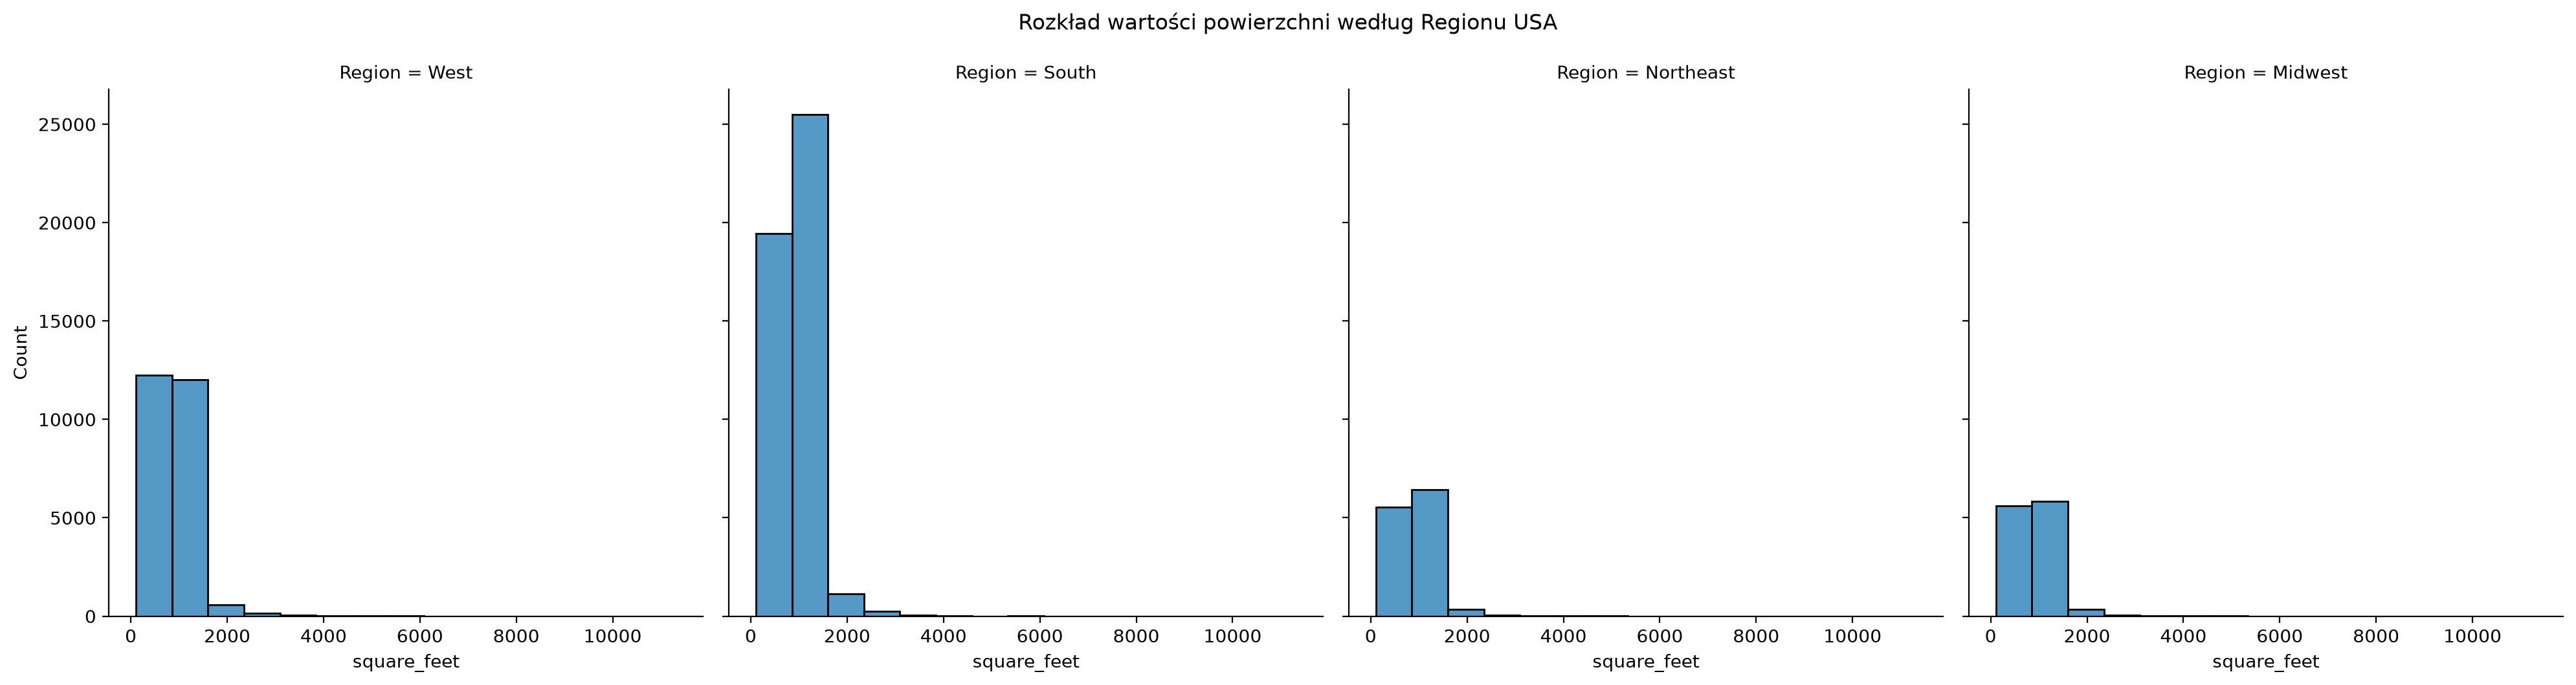

In [47]:
sns.displot(
    data=df,
    x="square_feet",
    col="Region",
    bins=15
)

plt.suptitle("Rozkład wartości powierzchni według Regionu USA", y=1.05)
plt.show()

In [62]:
df1 = df[(df["square_feet"] <= 2500) ]
df1["bin_square_feet"] = pd.cut(
    df1["square_feet"],
    bins=[300, 500, 700, 1000, 1500, 2000, 2500, float("inf")],
    labels=["0-300", "300-500", "500-700", "700-1000", "1000-1500",
            "1500-2000","2000-2500"]
)
#df1.head(4)
fig = px.histogram(df1, x="bin_square_feet", color="Region")
fig.show()

In [55]:
fig = px.bar(
    df1,
    x="Region",
    color="bin_square_feet",
    opacity=1.0,  # pełna intensywność
)

fig.show()

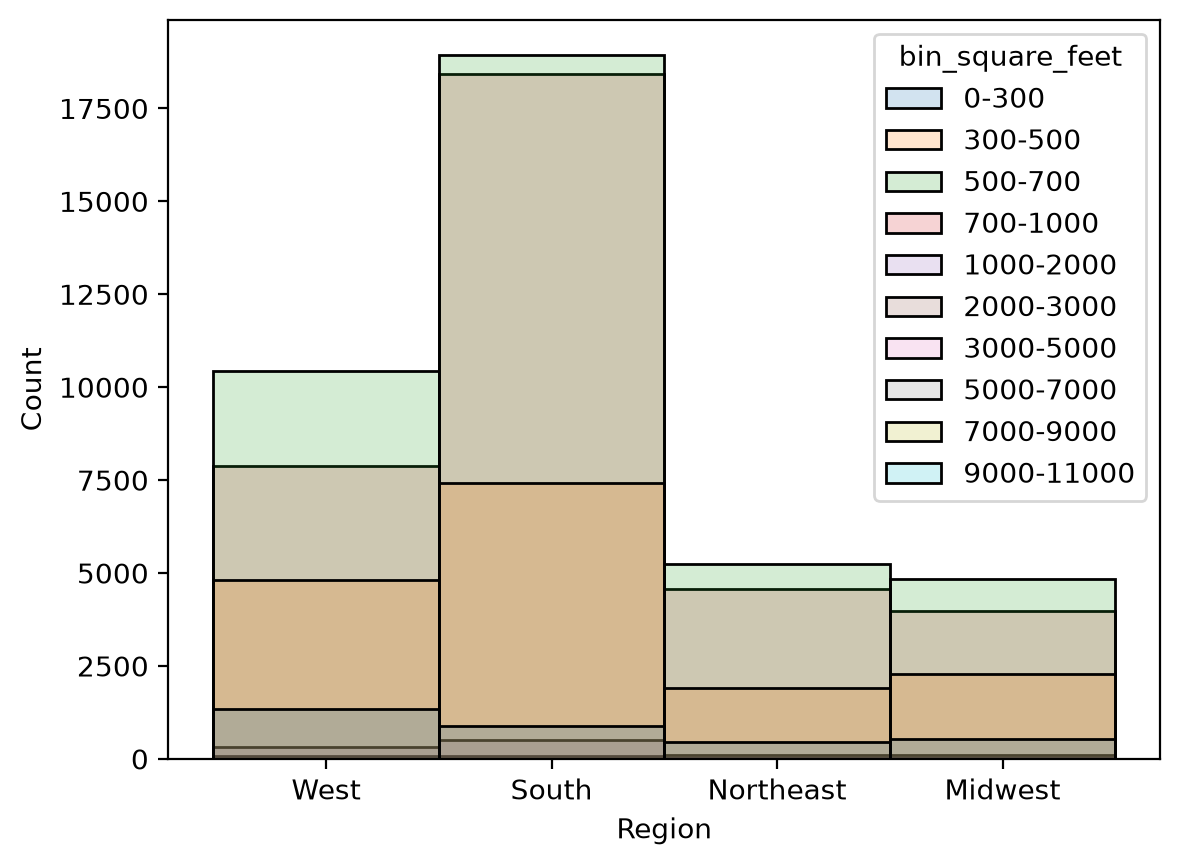

In [42]:
w= sns.histplot(df1, x='Region',hue = 'bin_square_feet', alpha=.2)

TypeError: The x variable is categorical, but one of ['numeric', 'datetime'] is required

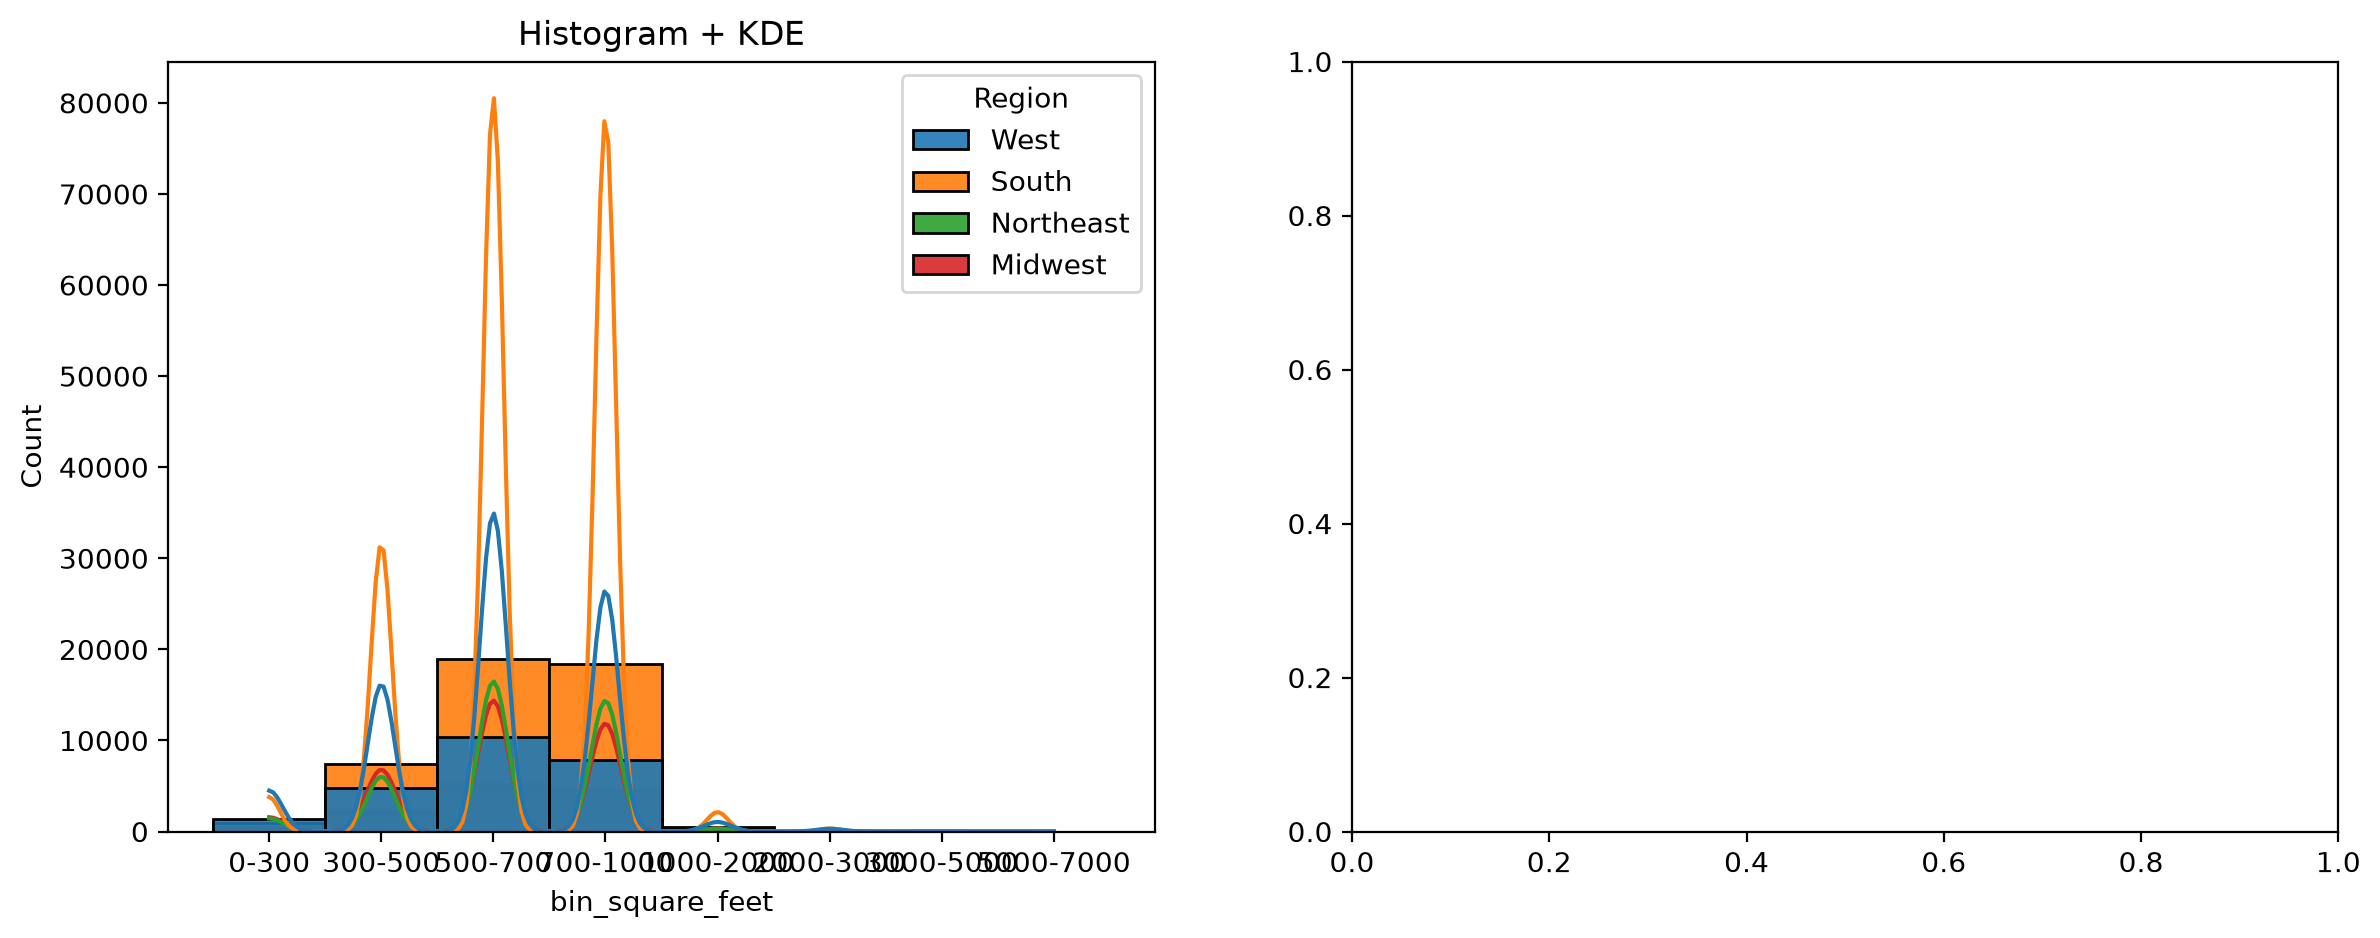

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    df1,
    x='bin_square_feet',
    kde=True,
    hue='Region',
    alpha=.9,
    ax=axes[0]
)
axes[0].set_title('Histogram + KDE')

sns.kdeplot(
    df1,
    x='bin_square_feet',
    hue='Region',
    alpha=.9,
    multiple='stack',
    ax=axes[1]
)
axes[1].set_title('KDE stacked')

plt.tight_layout()
plt.show()